In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, Operator, DensityMatrix, partial_trace, Kraus
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from scipy.linalg import expm
import matplotlib.pyplot as plt

In [2]:
#statevectors for z basis eigenstates
state_00 = Statevector.from_label("00")
state_01 = Statevector.from_label("01")
state_10 = Statevector.from_label("10")
state_11 = Statevector.from_label("11")
sm  = np.array([[0,1],[0,0]], dtype=complex)   # |0><1|
sm_S = np.kron(sm, np.eye(2))                  # lowering on the system qubit
sm_A = np.kron(np.eye(2), sm)                  # lowering on the ancilla qubit
flipflop = sm_S @ sm_A.conj().T + sm_S.conj().T @ sm_A
test_op = Operator(np.eye(4) - 2*np.outer(state_10.data, state_10.data.conj())) # to make sure indexing matches with circuit

In [3]:
qc = QuantumCircuit(2)
qc.x(0)
qc.append(test_op, [0,1])
state = Statevector.from_instruction(qc)
state.draw('latex')

<IPython.core.display.Latex object>

In [4]:
qc = QuantumCircuit(2)
qc.x(1)
qc.append(test_op, [0,1])
state = Statevector.from_instruction(qc)
state.draw('latex')

<IPython.core.display.Latex object>

### All qubit collision model

In [5]:
# pre calculating the gibbs state for the system qubit
g = 2
g_z = 0.1
beta = 0.8
H = g* flipflop + g_z * np.kron(np.array([[1,0],[0,-1]]),np.array([[1,0],[0,-1]]))
def gibbs(H, beta):
    W = expm(-beta * H)
    return W / np.trace(W)

target = gibbs(np.array([[0,0],[0,1]]), beta)


In [6]:
# simulation parameters

delta_t = 0.1
n_system, n_ancilla, n_rounds = 1, 1, 200

def all_qubit_collision_unitary(g, gz, delta_t):
    return Operator(np.exp(-2*1j*gz*delta_t) * np.outer(state_00.data, state_00.data.conj()) + np.outer(state_11.data, state_11.data.conj())
    + np.cos(g*delta_t) * (np.outer(state_01.data, state_01.data.conj()) + np.outer(state_10.data, state_10.data.conj()))
    -1j*np.sin(g*delta_t)*flipflop)

OP = all_qubit_collision_unitary(g, g_z, delta_t)

# The ancilla is re-prepared in the (generally mixed) Gibbs state `target` before every
# collision. qc.reset() can only reinitialize a qubit to |0>, and after the interaction
# the system and ancilla are entangled, so we can't stay in Statevector land either -
# tracing out the ancilla from an entangled pure state generally yields a *mixed* state
# for the system. So we drop the QuantumCircuit/Statevector approach for the collision
# loop and work with density matrices directly, doing the trace-out + re-preparation by
# hand each round:
#   1. rho_joint = rho_A (fixed Gibbs state) ⊗ rho_S   (fresh ancilla each round)
#   2. rho_joint <- OP · rho_joint · OP†                (the collision)
#   3. rho_S <- Tr_A[rho_joint]                          (trace out the ancilla)

rho_A = DensityMatrix(target)          # ancilla is always reset to this Gibbs state
rho_S = DensityMatrix.from_label("0")  # initial system state

# rho_A.tensor(rho_S) puts rho_S on qubit 0 and rho_A on qubit 1, matching the
# [sys_reg, anc_reg] qarg ordering OP was built/verified against above.
history = [rho_S]
for _ in range(n_rounds):
    rho_joint = rho_A.tensor(rho_S)
    rho_joint = rho_joint.evolve(OP, qargs=[0, 1])
    rho_S = partial_trace(rho_joint, [1])  # trace out the ancilla (qubit 1)
    history.append(rho_S)

rho_S.draw('latex')

<IPython.core.display.Latex object>

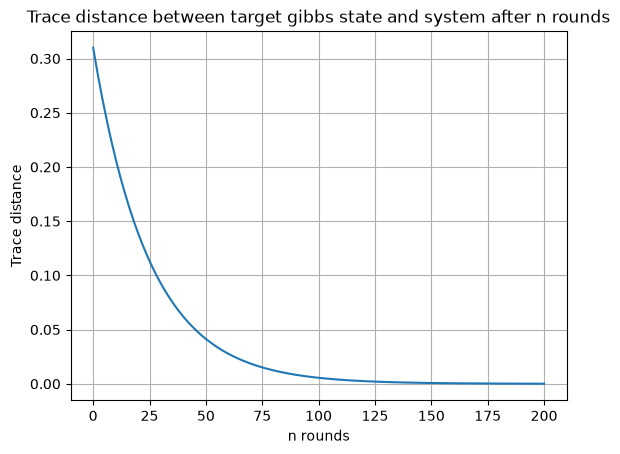

In [7]:
target_dens = DensityMatrix(target)
trace_dist = [0.5 * np.trace(np.abs(rho_S.data - target_dens.data)) for rho_S in history]
plt.plot(np.linspace(0, n_rounds, n_rounds+1), trace_dist)
plt.title('Trace distance between target gibbs state and system after n rounds')
plt.xlabel('n rounds')
plt.ylabel('Trace distance')
plt.grid()
plt.show()

### Adding noise

`DensityMatrix.evolve()` accepts any quantum channel, not just unitaries - so noise is just
another `.evolve(channel, qargs=...)` call inserted at whichever physical step it models.
Two common sources here: an imperfect collision (noisy `OP`), and an imperfect ancilla
reset/thermalization (noisy `rho_A`). `depolarizing_error` returns a `QuantumError`; wrap it
in `Kraus(...)` to use it with `DensityMatrix`/`Statevector` objects directly.

In [8]:
# noise on the collision itself (e.g. imperfect coupling/gate)
p_gate = 0.05
gate_noise = Kraus(depolarizing_error(p_gate, 2))

# noise on the ancilla reset/thermalization (e.g. imperfect bath contact)
p_prep = 0.02
prep_noise = Kraus(depolarizing_error(p_prep, 1))

rho_S = DensityMatrix.from_label("0")
history_noisy = [rho_S]
for _ in range(n_rounds):
    rho_A_noisy = rho_A.evolve(prep_noise, qargs=[0])       # imperfect ancilla prep
    rho_joint = rho_A_noisy.tensor(rho_S)
    rho_joint = rho_joint.evolve(OP, qargs=[0, 1])
    rho_joint = rho_joint.evolve(gate_noise, qargs=[0, 1])  # imperfect collision
    rho_S = partial_trace(rho_joint, [1])
    history_noisy.append(rho_S)

rho_S.draw('latex')

<IPython.core.display.Latex object>

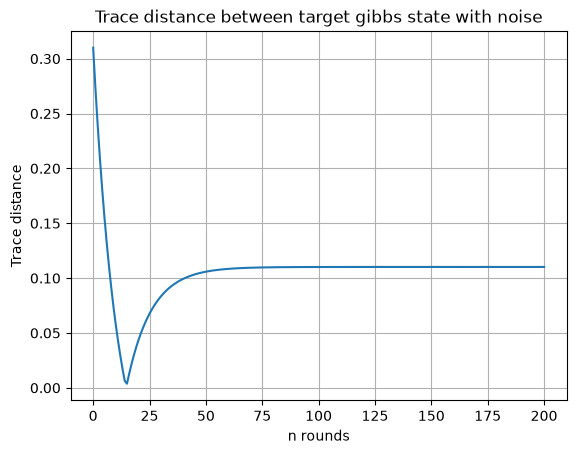

0.003777302135232502


In [9]:
target_dens = DensityMatrix(target)
trace_dist = [0.5 * np.trace(np.abs(rho_S.data - target_dens.data)) for rho_S in history_noisy]
plt.plot(np.linspace(0, n_rounds, n_rounds+1), trace_dist)
plt.title('Trace distance between target gibbs state with noise')
plt.xlabel('n rounds')
plt.ylabel('Trace distance')
plt.grid()
plt.show()
print(min(trace_dist))

### 5-qubit system, 1 shared ancilla (6-qubit working space)

Generalizes the single system-qubit collision model above to a system of 5 qubits
that share **one** bath ancilla. Each round, a single ancilla is freshly prepared
in the Gibbs state `η(β)` of a bare two-level system (`H_A = diag(0,1)`) at inverse
temperature `β`, using the same `gibbs(H, beta)` helper as the 1-qubit example above:

`η(β) = (1−p)|0⟩⟨0| + p|1⟩⟨1|`, with `p = 1/(1 + e^β)`

The ancilla collides with the system qubits **in sequence** (qubit 0, then 1, ...,
then 4) via the partial-swap unitary

`U(θ) = exp[−iθ(σ_S⁺σ_A⁻ + σ_S⁻σ_A⁺)]`

which is just `exp(-iθ·flipflop)` for the `flipflop` operator already defined above
(σ_S⁺σ_A⁻ + σ_S⁻σ_A⁺ = sm_S·sm_A† + sm_S†·sm_A). Only *after* colliding with all 5
system qubits is the ancilla traced out — so the working register during a round is
6 qubits (5 system + 1 ancilla), and because the same ancilla carries information
from one collision to the next, it mediates correlations between the system qubits
(unlike an "independent fresh ancilla per qubit" version, which would factorize
trivially).

Since each system qubit still swaps population with the *same* fixed bath state
`η(β)` every round, `η(β)^{⊗5}` remains the fixed point of the map — but qubits
later in the collision order (which meet an ancilla that's already partially
thermalized with earlier qubits) approach it more slowly than qubit 0 does.

In [10]:
# --- partial-swap collision unitary and bath (ancilla) state ---

def partial_swap_unitary(theta):
    """U(theta) = exp[-i*theta*(sigma_S^+ sigma_A^- + sigma_S^- sigma_A^+)]
    acting on (system, ancilla); equals exp(-i*theta*flipflop)."""
    return Operator(expm(-1j * theta * flipflop))

def bath_state(beta):
    """eta(beta) = Gibbs state of a bare two-level system (H_A = diag(0,1)) at inverse
    temperature beta, i.e. (1-p)|0><0| + p|1><1| with p = 1/(1+exp(beta)); reuses the
    `gibbs` helper defined for the 1-qubit example above."""
    return DensityMatrix(gibbs(np.array([[0, 0], [0, 1]]), beta))

In [11]:
# --- dynamical map: one round of collisions, 5 system qubits + 1 shared ancilla ---

n_sys = 5

def dynamical_map(rho_S, theta, beta, n_sys=n_sys):
    """
    Apply one round of the collision model to the n_sys-qubit system state rho_S:
    a single fresh ancilla (prepared in eta(beta)) collides in sequence with every
    system qubit (0, 1, ..., n_sys-1) via U(theta), and is then traced out.

    Working register while the ancilla is attached: qubits [0, n_sys) are the
    system (rho_S's own internal order), qubit n_sys is the ancilla. Because the
    same ancilla collides with each system qubit in turn, it can carry
    correlations from one collision to the next - this is a genuinely 6-qubit
    (n_sys + 1) evolution, not n_sys independent 2-qubit ones.
    """
    U = partial_swap_unitary(theta)
    eta = bath_state(beta)

    rho_joint = eta.tensor(rho_S)  # rho_S -> qubits [0, n_sys), ancilla -> qubit n_sys
    for i in range(n_sys):
        rho_joint = rho_joint.evolve(U, qargs=[i, n_sys])

    return partial_trace(rho_joint, [n_sys])

In [12]:
# simulation parameters
theta = 0.3
beta = 0.8  # inverse temperature of the bath ancilla, same convention/value as the
            # 1-qubit gibbs example above (this reassigns the earlier `beta` global)
n_rounds = 2000 

rho_S = DensityMatrix.from_label("0" * n_sys)
history_5q = [rho_S]
for _ in range(n_rounds):
    rho_S = dynamical_map(rho_S, theta, beta)
    history_5q.append(rho_S)

rho_S.draw('latex')

<IPython.core.display.Latex object>

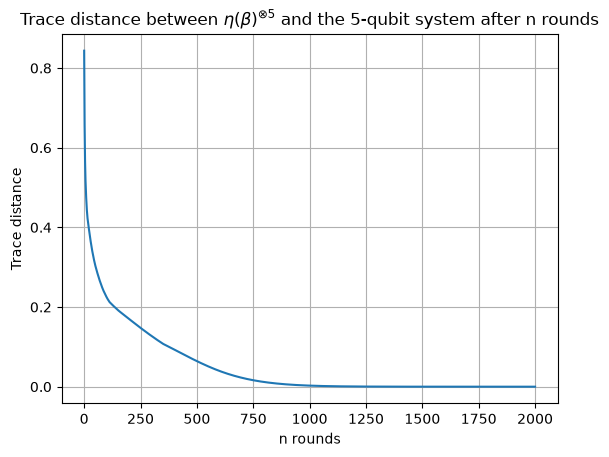

In [13]:
# target/steady state: eta(beta)^{otimes 5} is still the fixed point of the map (each
# system qubit keeps swapping population with the same fixed bath state eta(beta)), even
# though the shared ancilla mediates transient correlations along the way
target_5q = bath_state(beta)
for _ in range(n_sys - 1):
    target_5q = target_5q.tensor(bath_state(beta))

trace_dist_5q = [0.5 * np.trace(np.abs(rho.data - target_5q.data)) for rho in history_5q]
plt.plot(np.linspace(0, n_rounds, n_rounds + 1), trace_dist_5q)
plt.title(r'Trace distance between $\eta(\beta)^{\otimes 5}$ and the 5-qubit system after n rounds')
plt.xlabel('n rounds')
plt.ylabel('Trace distance')
plt.grid()
plt.show()

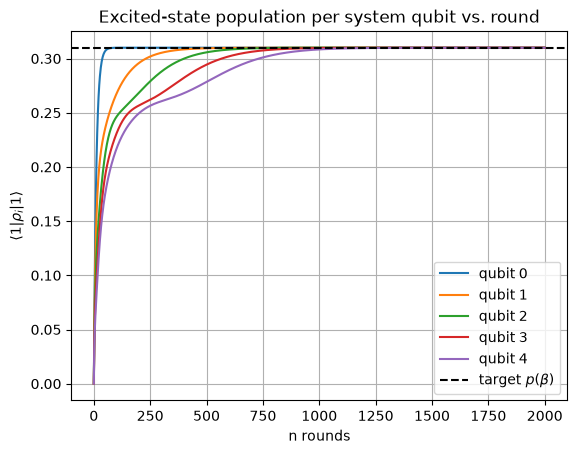

In [14]:
# per-qubit <1| population vs. round: since the shared ancilla collides with qubit 0
# first and qubit 4 last each round, qubit 0 thermalizes fastest and qubit 4 slowest
p_target = bath_state(beta).data[1, 1].real

populations = np.zeros((n_sys, len(history_5q)))
for i in range(n_sys):
    others = [j for j in range(n_sys) if j != i]
    for t, rho in enumerate(history_5q):
        populations[i, t] = partial_trace(rho, others).data[1, 1].real

for i in range(n_sys):
    plt.plot(populations[i], label=f'qubit {i}')
plt.axhline(p_target, color='k', linestyle='--', label=r'target $p(\beta)$')
plt.title('Excited-state population per system qubit vs. round')
plt.xlabel('n rounds')
plt.ylabel(r'$\langle 1|\rho_i|1\rangle$')
plt.legend()
plt.grid()
plt.show()